### Load Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
import sqlite3

conn = sqlite3.connect("../database/regression.db")
df = pd.read_sql("SELECT * FROM predicting_sales", conn)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


### Understand Data

In [26]:
df.shape

(1017209, 9)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [28]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


### Check Missing Values

In [32]:
## Check for missing values
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

### Clean Data & Feature Engineering

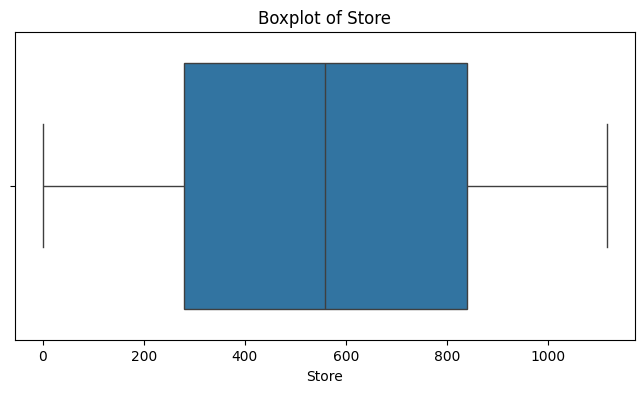

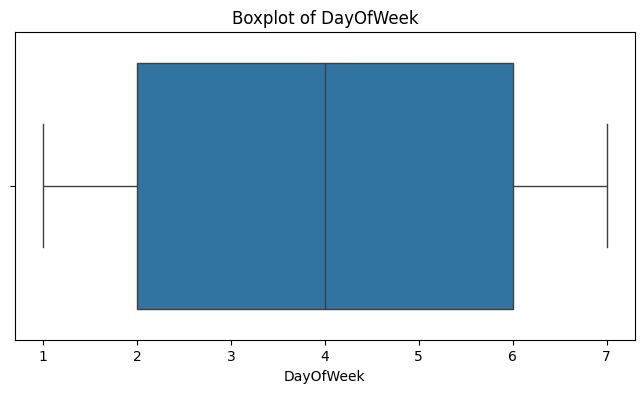

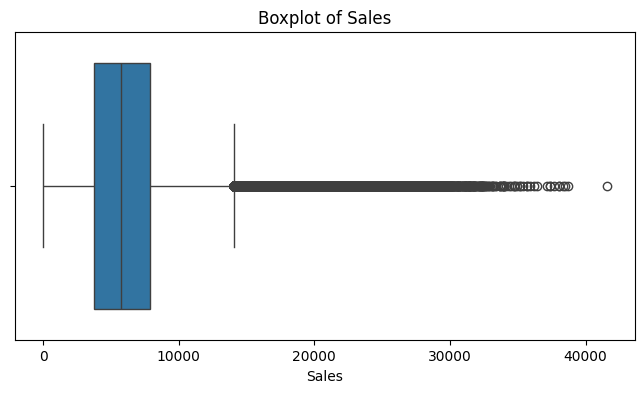

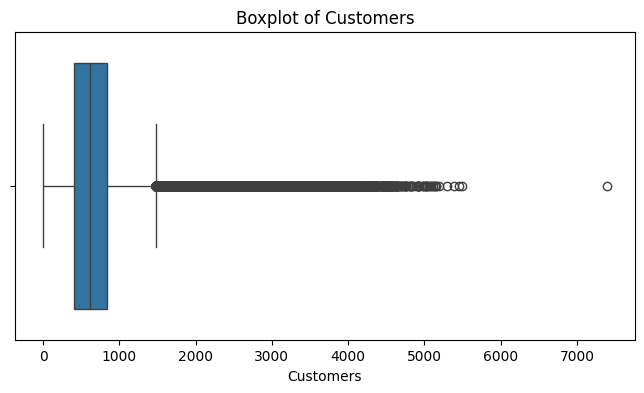

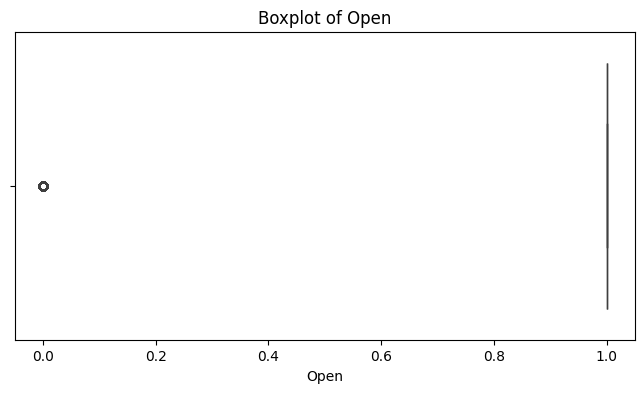

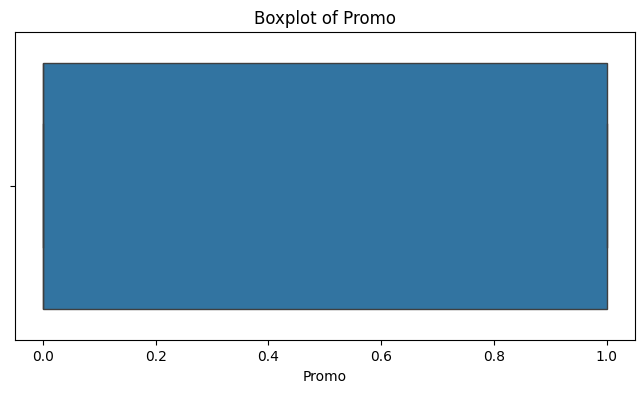

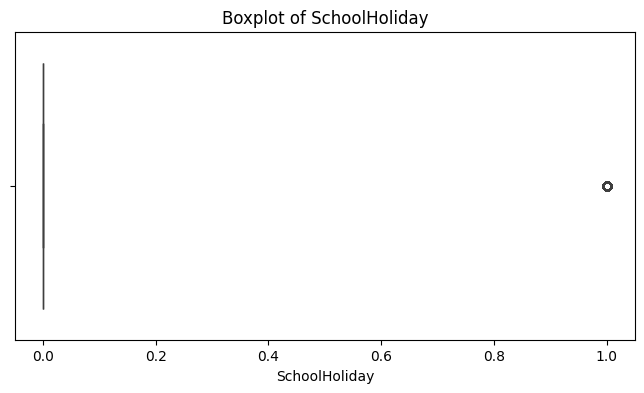

In [36]:
# No missing values found. Proceeding with EDA.
# Remove duplicate rows if any
df.drop_duplicates(inplace=True)

# Check for outliers using boxplots
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [37]:
# Detect outliers using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'Outliers in {col}: {len(outliers)}')

Outliers in Store: 0
Outliers in DayOfWeek: 0
Outliers in Sales: 26694
Outliers in Customers: 38095
Outliers in Open: 172817
Outliers in Promo: 0
Outliers in SchoolHoliday: 181721


## Observations:

### 1. Store column:
| Metric | Value |
| ------ | ----- |
| min    | 1     |
| max    | 1115  |

This means there are 1115 stores.
This column is an identifier, not a feature with numeric meaning.
Usually we keep it as categorical / ID.

### 2. DayOfWeek:
Mean ≈ 4
So average day is around Thursday.
This feature is important for sales prediction.

### 3. Sales (Target Variable):
| Metric | Value |
| ------ | ----- |
| mean   | 5773  |
| median | 5744  |
| max    | 41551 |
| min    | 0     |

* Sales = 0 means store was closed
* Mas Sales = 41551
* So 41551 is likely an outlier.

## 4. Open (Store)
* Mean = 0.83, means 83% of rows = store open (Sales=0, Customers=0)
* 17% = store closed
* So many models remove closed days.

## 5. Promo:
* Mean = 0.38, meaning 38% days have promotion
* This is a very strong feature for sales prediction

## 6. SchoolHoliday:
* Mean = 0.17, meaning 17% of days are school holidays.
* This also affects customer traffic.




# Data Visualization & EDA

### 1. Sales distribution

<Axes: xlabel='Sales', ylabel='Count'>

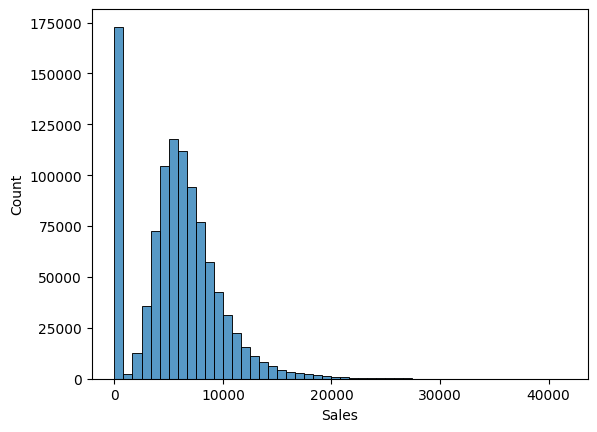

In [40]:
sns.histplot(df["Sales"], bins=50)

In [41]:
df[df["Sales"] == 0][["Open","Customers"]].head()

,Open,Customers
291,0,0
875,0,0
1406,0,0
1990,0,0
2521,0,0


In [47]:
# Remove rows where Sales is 0 and Open is 1, as these are likely data errors or special cases that won't help the model learn general patterns.
df = df[(df["Open"] == 1) & (df["Sales"] > 0)]

# Right-Skewed Distribution shown in histogram, meaning Most sales are around 3000–8000, Few very large values exist (long tail)
# But tree models (Random Forest, LightGBM, XGBoost) usually don't require it.


In [48]:
df[df["Sales"] == 0][["Open","Customers"]].head()

,Open,Customers


### 2. Promotional Impact:

<Axes: xlabel='Promo', ylabel='Sales'>

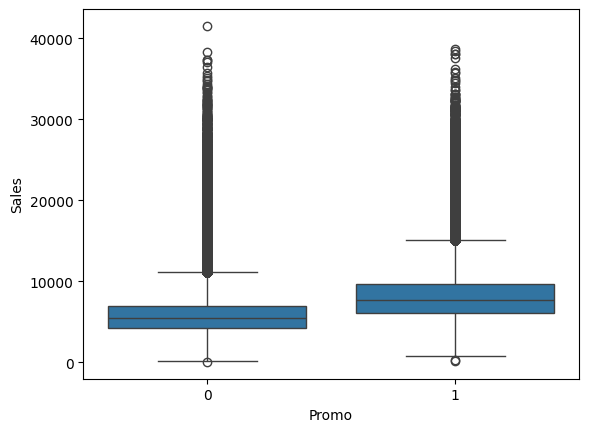

In [49]:
sns.boxplot(x="Promo", y="Sales", data=df)

#### Conlusion:

| Promo | Median Sales |
| ----- | ------------ |
| 0     | ~5500        |
| 1     | ~7500        |

* This means Stores earn more when promotions are running.
* +2000 sales on average
* This is a strong predictive feature.\
Your ML model will heavily rely on it.\
Tree models like:\
• Random Forest\
• LightGBM\
• XGBoost\
usually learn this relationship very well.

Promotions increase both:\
• average sales\
• variability in sales\
• Outlier is not an Error, as sales increased during promotions

### 3. Sales by day of week

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

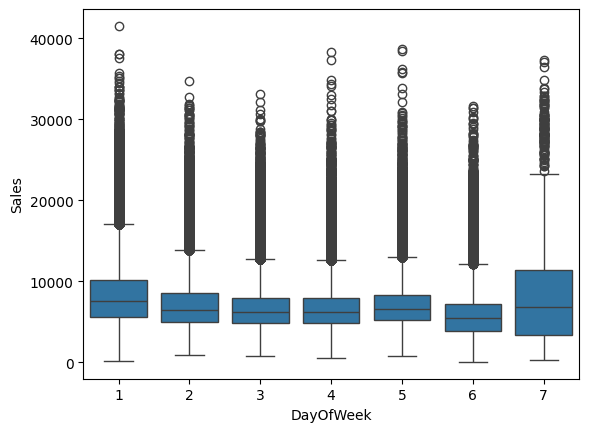

In [50]:
sns.boxplot(x="DayOfWeek", y="Sales", data=df)

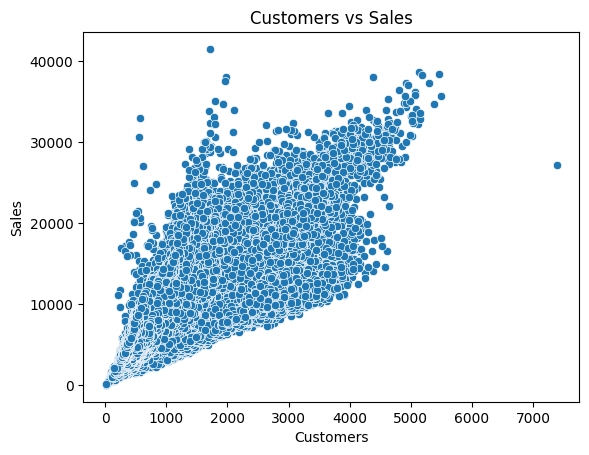

In [99]:
# Check liniear relationship between numerical features and Sales
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["Customers"], y=df["Sales"])
plt.title("Customers vs Sales")
plt.show()

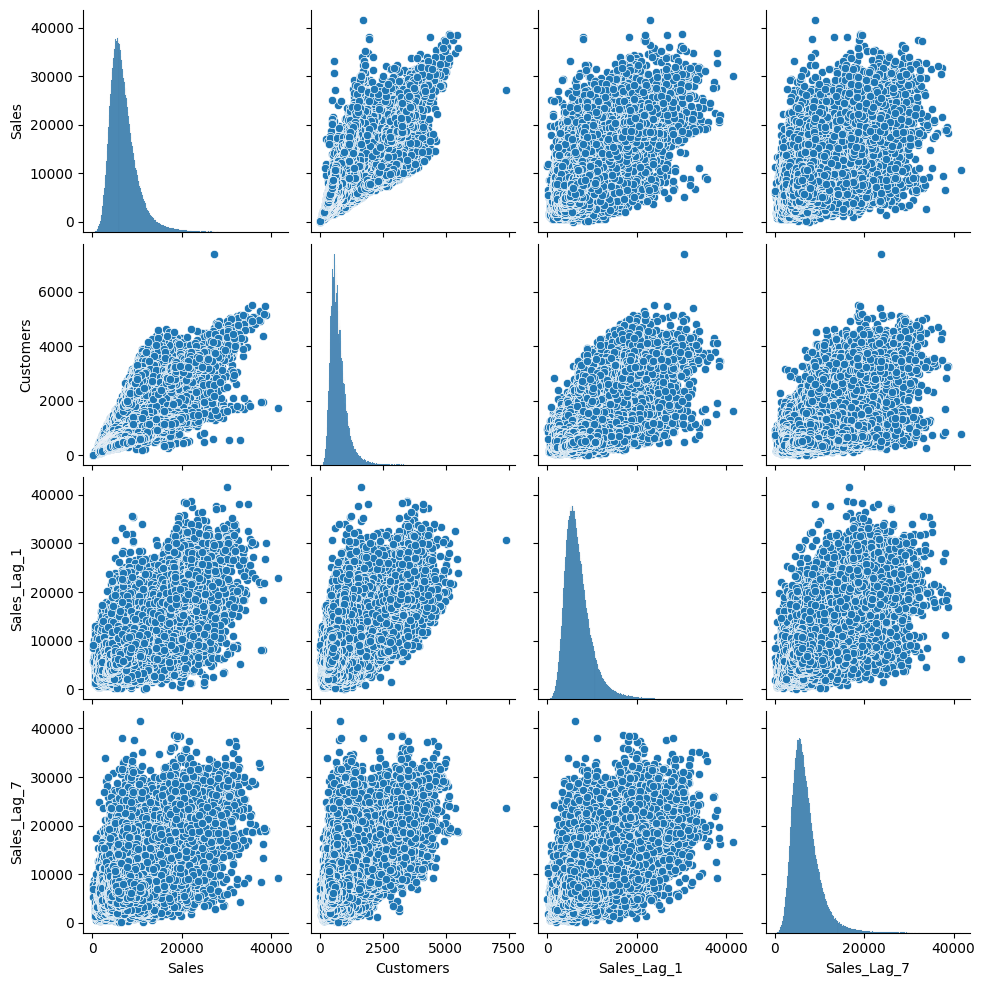

In [102]:
sns.pairplot(df[["Sales","Customers","Sales_Lag_1","Sales_Lag_7"]])

### Conlusion:
* Saturday and Monday also show higher sales
* Some stores are closed on Sunday\
but some open stores generate very high sales\

All days show many high outliers.\

These are probably:
* very large stores
* holiday shopping days
* heavy promotions\
They are not necessarily errors.

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

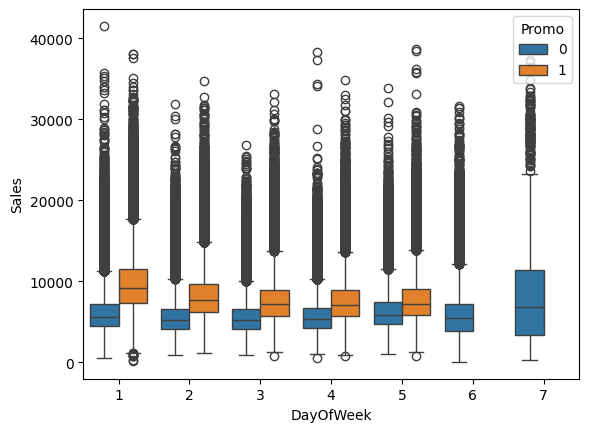

In [51]:
sns.boxplot(x="DayOfWeek", y="Sales", hue="Promo", data=df)

## Key Insights From Your EDA So Far:
1️⃣ Promotions increase sales\
2️⃣ Day of week influences sales\
3️⃣ Many sales outliers exist\
4️⃣ Sales distribution is right-skewed

### 4. Correlation Heatmap:

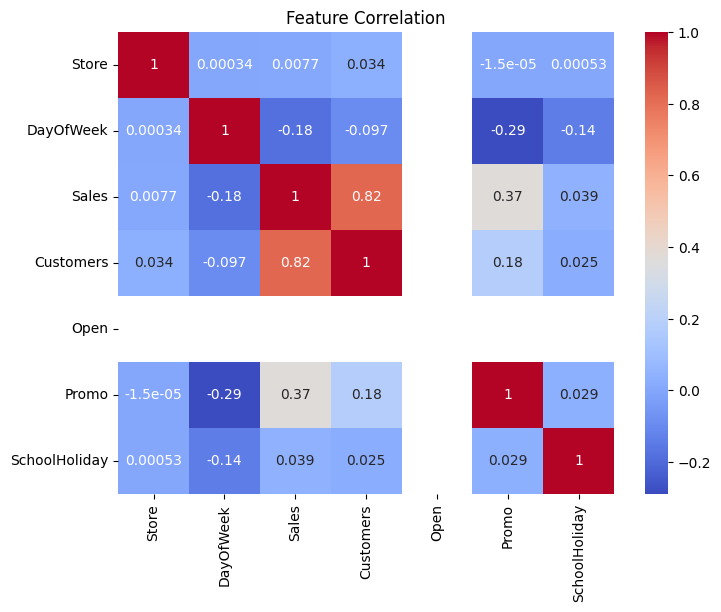

In [54]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()

## Conclusion of Correlation Heatmap:
### 1. Strongest Relationship: Customers ↔ Sales (More customers → higher sales)
### 2. More customers → higher sales , this is a moderate positive correlation.
### 3. DayOfWeek Effect - Certain days have slightly lower sales, But correlation may not capture the full pattern, because day-of-week effects are non-linear (e.g., weekends).
### 4. SchoolHoliday Effect - School holidays don't strongly affect sales overall.School holidays don't strongly affect sales overall.
### 5. Store number itself has no numeric meaning, But the store may still matter because different stores behave differently.

| Feature       | Importance |
| ------------- | ---------- |
| Customers     | ⭐⭐⭐⭐⭐   |
| Promo         | ⭐⭐⭐⭐     |
| DayOfWeek     | ⭐⭐⭐       |
| SchoolHoliday | ⭐          |
| Store         | depends     |

If your goal is predicting sales before the day starts, you may not know customer count yet.
So sometimes models exclude Customers.


## Feature Engineering Steps:
### 1. Extract Time-Based Features from Date

In [55]:
#Retail sales follow seasonal patterns (months, weeks, weekends).
#First ensure date is datetime:
df["Date"] = pd.to_datetime(df["Date"])

#Then extract features: 
df["Year"] = df["Date"].dt.year  # Year can capture long-term trends, economic cycles, or changes in consumer behavior over time.
df["Month"] = df["Date"].dt.month # Month can capture Seasonal Sales, holidays, and weather-related effects on sales.
df["Day"] = df["Date"].dt.day # Day of month can capture end-of-month sales patterns, paydays, or specific date-related promotions.
df["WeekOfYear"] = df["Date"].dt.isocalendar().week # Week of year can capture weekly sales patterns, promotional cycles, and seasonality that may not align perfectly with calendar months.
df["IsWeekend"] = df["DayOfWeek"].isin([6,7]).astype(int) # IsWeekend can capture differences in shopping behavior between weekdays and weekends, which is common in retail sales data.

### 2. Extract Time-Based Features from Date
Promotion Interaction Features

In [56]:
df["Promo_Weekend"] = df["Promo"] * df["IsWeekend"] # This tells that , Promotion on weekend = extra high sales
df["Promo_DayOfWeek"] = df["Promo"] * df["DayOfWeek"]
df.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,IsWeekend,Promo_Weekend,Promo_DayOfWeek
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,31,0,0,5
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,31,0,0,5
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,31,0,0,5
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,31,0,0,5
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,31,0,0,5


### 3. Lag / Historical Sales Features (Very Powerful)
Sales are strongly related to previous sales.

For example:

| Feature     | Meaning           |
| ----------- | ----------------- |
| Sales_Lag_1 | yesterday's sales |
| Sales_Lag_7 | sales last week   |


In [64]:
# Always sort data before creating lag features. Otherwise lag values will be incorrect.
df = df.sort_values(by=["Store", "Date"])

df["Sales_Lag_1"] = df.groupby("Store")["Sales"].shift(1)
df["Sales_Lag_7"] = df.groupby("Store")["Sales"].shift(7)

df_clean = df.dropna().copy() # Drop rows with NaN values created by lag features

print(df.shape)
print(df_clean.shape)

df_clean.head()

(844338, 18)
(836533, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,IsWeekend,Promo_Weekend,Promo_DayOfWeek,Sales_Lag_1,Sales_Lag_7
1006060,1,4,2013-01-10,4892,615,1,1,0,1,2013,1,10,2,0,0,4,5471.0,5530.0
1004945,1,5,2013-01-11,4881,592,1,1,0,1,2013,1,11,2,0,0,5,4892.0,4327.0
1003830,1,6,2013-01-12,4952,646,1,0,0,0,2013,1,12,2,1,0,0,4881.0,4486.0
1001600,1,1,2013-01-14,4717,616,1,0,0,0,2013,1,14,3,0,0,0,4952.0,4997.0
1000485,1,2,2013-01-15,3900,512,1,0,0,0,2013,1,15,3,0,0,0,4717.0,7176.0


### 4. Rolling Average Features:

IF Promo = 1 AND Weekend → high sales\
IF Month = December → very high sales\
IF last week sales were high → today likely high

In [65]:
# This gives average sales of the last 7 days. 
# It smooths noise and improves predictions.
df_clean["Sales_Rolling_7"] = df_clean.groupby("Store")["Sales"].transform(
    lambda x: x.rolling(7).mean()
)


### What You Have Built So Far
You already created 3 powerful time-series features:

| Feature         | Meaning                |
| --------------- | ---------------------- |
| Sales_Lag_1     | yesterday's sales      |
| Sales_Lag_7     | last week's sales      |
| Sales_Rolling_7 | average of last 7 days |

Proper ML Workflow:

EDA \
↓\
Feature Engineering\
↓\
Train/Test Split\
↓\
Train Multiple Models\
↓\
Evaluate Metrics\
↓\
Choose Best Model


In [71]:
df.isnull().sum()

Store                 0
DayOfWeek             0
Date                  0
Sales                 0
Customers             0
Open                  0
Promo                 0
StateHoliday          0
SchoolHoliday         0
Year                  0
Month                 0
Day                   0
WeekOfYear            0
IsWeekend             0
Promo_Weekend         0
Promo_DayOfWeek       0
Sales_Lag_1        1115
Sales_Lag_7        7805
dtype: int64

In [79]:
df_clean = df.dropna(subset=["Sales_Lag_1", "Sales_Lag_7"]).copy()
df_clean["StateHoliday"] = df_clean["StateHoliday"].astype(str)
df_clean["StateHoliday"] = df_clean["StateHoliday"].map({
    "0": 0,
    "a": 1,
    "b": 2,
    "c": 3
})


In [76]:
df_clean.isnull().sum()

Store              0
DayOfWeek          0
Date               0
Sales              0
Customers          0
Open               0
Promo              0
StateHoliday       0
SchoolHoliday      0
Year               0
Month              0
Day                0
WeekOfYear         0
IsWeekend          0
Promo_Weekend      0
Promo_DayOfWeek    0
Sales_Lag_1        0
Sales_Lag_7        0
dtype: int64

## Train Model

In [88]:
# Step 1. Prepare Features and Target for modeling
y = df_clean["Sales"] # Target variable is Sales, which we want to predict.
X = df_clean.drop(columns=["Sales", "Date"]) # Features are all columns except Sales

In [89]:
print("Number of infinite values in X:", np.isinf(X).sum())
print("Number of NaN values in X:", np.isnan(X).sum())

Number of infinite values in X: Store              0
DayOfWeek          0
Customers          0
Open               0
Promo              0
StateHoliday       0
SchoolHoliday      0
Year               0
Month              0
Day                0
WeekOfYear         0
IsWeekend          0
Promo_Weekend      0
Promo_DayOfWeek    0
Sales_Lag_1        0
Sales_Lag_7        0
dtype: Int64
Number of NaN values in X: Store              0
DayOfWeek          0
Customers          0
Open               0
Promo              0
StateHoliday       0
SchoolHoliday      0
Year               0
Month              0
Day                0
WeekOfYear         0
IsWeekend          0
Promo_Weekend      0
Promo_DayOfWeek    0
Sales_Lag_1        0
Sales_Lag_7        0
dtype: Int64


In [93]:
# Step 2. Train-Test Split
# For time-series data it is better to split chronologically instead of random split. This prevents data leakage from future to past.

split_index = int(len(df_clean) * 0.8) # 80% for training, 20% for testing
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]   
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Min max scaling needed to numerical columns for linear regression, but tree models can handle unscaled data. So we will keep original values for tree models and only scale for linear regression if needed.  
from sklearn.preprocessing import MinMaxScaler

num_cols = X.select_dtypes(include=['int64','float64']).columns

scaler = MinMaxScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

/var/folders/mx/7g7vc2z57yb66gbrj5fy81mm0000gn/T/ipykernel_6068/317215816.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
/var/folders/mx/7g7vc2z57yb66gbrj5fy81mm0000gn/T/ipykernel_6068/317215816.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[num_cols] = scaler.transform(X_test[num_cols])


In [96]:



print(f'Training set: {X_train.shape}, {y_train.shape}')
print(f'Testing set: {X_test.shape}, {y_test.shape}')

# Step 3. Train multiple models and compare performance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor()
}

# Train and evaluate each model

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="RMSE")


Training set: (669226, 16), (669226,)
Testing set: (167307, 16), (167307,)


/Users/puruhirave/AI-Projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/puruhirave/AI-Projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/puruhirave/AI-Projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Model,MAE,RMSE,R2
3,Gradient Boosting,776.402563,1093.143394,0.860025
2,Random Forest,767.427025,1189.328945,0.834308
0,Linear Regression,948.760143,1335.653240,0.791029
1,Decision Tree,1078.030686,1641.774611,0.684264


<Axes: xlabel='Model'>

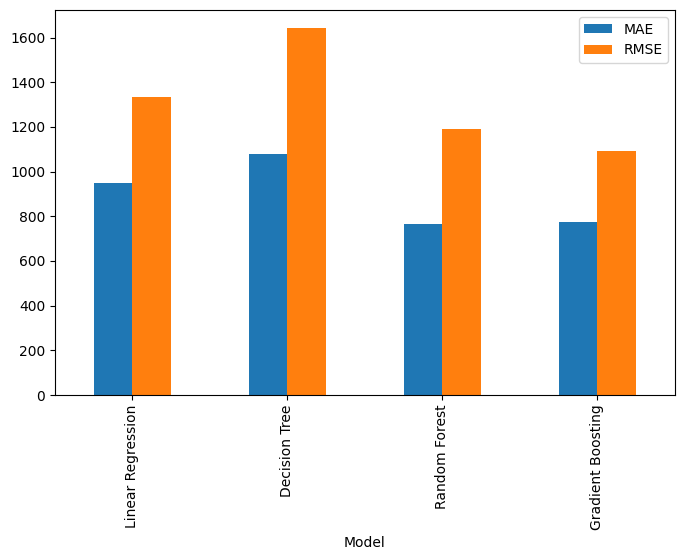

In [97]:
results_df.set_index("Model")[["MAE","RMSE"]].plot(kind="bar", figsize=(8,5))

# Interpretation:

Focus mainly on:

| Metric | Meaning                  |
| ------ | ------------------------ |
| MAE    | average prediction error |
| RMSE   | penalizes large mistakes |
| R²     | variance explained       |

For regression models:
* Lower MAE and RMSE → better
* Higher R² → better

## Why Gradient Boosting Wins?

Gradient boosting works well because your dataset has:
* nonlinear relationships
* interactions (Promo × DayOfWeek)
* lag features
* time patterns

These patterns are **not linear**, so tree boosting models perform better.